# Basics of Linear Algebra

This notebook reviews the linear algebra you'll need for this course: vectors, matrices, and a handful of core operations. Rather than covering these topics in the abstract, we'll use a running example throughout -- a simple portfolio of risky assets -- to show why this machinery is useful for finance, not just how it works mechanically.

This notebook stops short of any portfolio *optimization* -- we build the tools here, and `MVPortfolio.ipynb` picks up right where this notebook leaves off, using these same tools to derive the minimum-variance and tangency portfolios.

*Acknowledgment*: This notebook was produced with the assistance of AI, based on the instructor's own handwritten course notes. I remain responsible for the content and any errors.

## Learning Objectives

By the end of this notebook, you should be able to:

1. Define a vector, and represent a set of portfolio weights and a set of asset returns as vectors in $\mathbb{R}^N$.
2. Perform vector addition, scalar multiplication, and subtraction, and interpret these operations in a portfolio context (e.g., rebalancing, leverage).
3. Compute the dot product of two vectors, and use it to (a) impose the portfolio restriction that weights sum to one and (b) compute portfolio return as $w \cdot R$.
4. Compute a vector's norm and the angle between two vectors; define the span of a set of vectors, and determine whether a set of vectors is linearly independent.
5. Define a matrix and perform matrix addition, scalar multiplication, and transpose; identify a symmetric matrix, using the covariance matrix $\Sigma$ as a running example.
6. Perform matrix multiplication by hand for small matrices, and compute it in Python with `numpy`.
7. Define the matrix inverse, and use it to solve a simple linear system $Ax = c$.
8. Recognize a quadratic form $w'\Sigma w$, and show -- both algebraically and numerically -- that it equals portfolio variance.
9. Write a multivariate linear regression model compactly in matrix form, $Y = X\beta + \epsilon$, and describe the dimensions of each component.

## Instructions to Run

**Data:** None -- this notebook works entirely with small, hand-specified vectors and matrices (portfolio weights, returns, and a covariance matrix), so there's nothing to download and no internet connection is required.

**Package dependencies:** `numpy` and `matplotlib`, both standard Anaconda packages.

**Viewing the HTML export in Canvas:** If equations show up as raw LaTeX source (e.g., `$...$`) instead of typeset math, don't use Canvas's built-in file preview -- download the file and open it locally in a browser instead.

## Why linear algebra?

Suppose you're managing a portfolio of $N=20$ risky assets. To describe the portfolio, you need 20 portfolio weights. To describe expected performance, you need 20 expected returns. To describe risk, you need a full $20 \times 20$ table of variances and covariances -- 400 numbers, most of them distinct.

Writing out formulas involving 20 (or 200, or 2,000) individual numbers with subscripts would be unreadable. **Vectors** let us bundle the 20 weights into a single object, $w$. **Matrices** let us bundle the covariance table into a single object, $\Sigma$. And a small set of vector/matrix *operations* -- addition, multiplication, the dot product, the inverse -- let us write compact formulas (like $w'\Sigma w$ for portfolio variance) that work no matter whether $N$ is 2 or 2,000.

That's the motivation for *this* notebook, but it's really a special case of something bigger: vectors and matrices are the common language behind a huge swath of quantitative finance and data science, not just portfolio math. Multivariate linear regression (which we'll get to below) writes an entire many-predictor model as one equation, $Y = X\beta + \epsilon$. Principal component analysis (PCA) -- used, for example, to summarize the dominant sources of co-movement across a large panel of asset returns or economic variables -- amounts to finding the eigenvectors of a covariance matrix. Machine learning methods from ridge regression to neural networks are built on this same vocabulary. We'll use the portfolio problem as our running example because it's concrete and it's this course's focus, but the tools themselves are general-purpose: linear algebra is the bookkeeping system that makes all of this tractable.

## Vectors

A **vector** is an ordered list -- an "$N$-tuple" -- of numbers. We write $\mathbb{R}^N$ for the set of all such lists of length $N$ (real numbers). A vector of length 2 lives in $\mathbb{R}^2$, a vector of length 3 in $\mathbb{R}^3$, and so on. A single number (a "$1 \times 1$" vector) is called a **scalar**.

For example:
$$\begin{pmatrix} 0 \\ 1 \end{pmatrix} \in \mathbb{R}^2, \qquad \begin{pmatrix} -1 \\ 0 \\ 1 \end{pmatrix} \in \mathbb{R}^3, \qquad 5 \in \mathbb{R}^1 \text{ (a scalar)}$$

By convention, when we don't specify otherwise, a vector is a **column vector** (numbers stacked vertically) rather than a **row vector** (numbers side by side). We'll come back to that distinction when we get to matrices.

Vectors can be visualized as points, or as arrows from the origin to those points, in $\mathbb{R}^2$ or $\mathbb{R}^3$ (this geometric picture gets harder to draw once $N>3$, but the algebra works the same way regardless of $N$). The code below plots the vector $(2, 1)$ as an arrow in the plane.

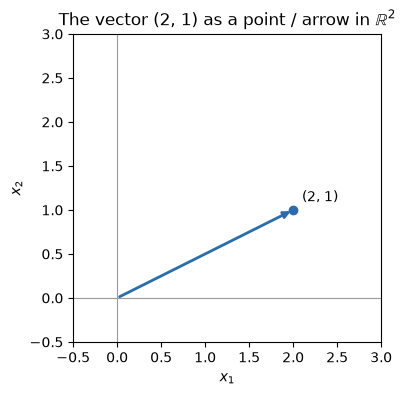

In [1]:
import numpy as np
import matplotlib.pyplot as plt

v = np.array([2, 1])

fig, ax = plt.subplots(figsize=(4, 4))
ax.axhline(0, color='0.6', linewidth=0.8)
ax.axvline(0, color='0.6', linewidth=0.8)
ax.annotate('', xy=v, xytext=(0, 0),
            arrowprops=dict(arrowstyle='-|>', color='#2b6cb0', linewidth=2))
ax.plot(*v, 'o', color='#2b6cb0')
ax.text(v[0] + 0.1, v[1] + 0.1, f'({v[0]}, {v[1]})')
ax.set_xlim(-0.5, 3)
ax.set_ylim(-0.5, 3)
ax.set_aspect('equal')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('The vector (2, 1) as a point / arrow in $\\mathbb{R}^2$')
plt.show()

### A financial example: the portfolio weight vector

Vectors don't have to represent points in physical space -- in finance, a vector is often just a convenient way to bundle a list of numbers, one per asset.

Suppose we're choosing how to allocate a portfolio between two assets: a stock ETF and a bond ETF. If we put 60% of our wealth in the stock ETF and 40% in the bond ETF, we can bundle those two numbers into a single **portfolio weight vector**:
$$w = \begin{pmatrix} w_{\text{stock}} \\ w_{\text{bond}} \end{pmatrix} = \begin{pmatrix} 0.6 \\ 0.4 \end{pmatrix} \in \mathbb{R}^2$$

More generally, with $N$ risky assets, $w$ is an $N \times 1$ vector with $n$-th entry $w_n$ equal to the fraction of wealth allocated to asset $n$. We'll use this exact setup -- $N$ assets, weight vector $w$ -- as a running example for the rest of this notebook.

In [2]:
# Portfolio weight vector: 60% stock ETF, 40% bond ETF
w = np.array([0.6, 0.4])
print('Portfolio weight vector w =', w)

Portfolio weight vector w = [0.6 0.4]


## Vector Operations

Three basic operations let us combine or rescale vectors:

- **Addition**: add the vectors element-wise. For example, $\begin{pmatrix}3\\0\\2\end{pmatrix} + \begin{pmatrix}0\\4\\3\end{pmatrix} = \begin{pmatrix}3\\4\\5\end{pmatrix}$.
- **Scalar multiplication**: multiply every element by the same scalar. For example, $2 \cdot \begin{pmatrix}4\\-2\\1\end{pmatrix} = \begin{pmatrix}8\\-4\\2\end{pmatrix}$.
- **Subtraction**: add $-1$ times the second vector (equivalently, subtract element-wise). For example, $\begin{pmatrix}4\\-2\\1\end{pmatrix} - \begin{pmatrix}2\\2\\2\end{pmatrix} = \begin{pmatrix}4\\-2\\1\end{pmatrix} + (-1)\begin{pmatrix}2\\2\\2\end{pmatrix} = \begin{pmatrix}2\\-4\\-1\end{pmatrix}$.

The **zero vector** (all entries zero) is the additive identity: adding it to any vector returns that vector unchanged.

`numpy` implements all of these directly on arrays -- no loops required:

In [3]:
a = np.array([3, 0, 2])
b = np.array([0, 4, 3])
print('a + b =', a + b)

c = np.array([4, -2, 1])
print('2 * c =', 2 * c)

d = np.array([2, 2, 2])
print('c - d =', c - d)

zero = np.zeros(3)
print('c + zero vector =', c + zero)

a + b = [3 4 5]
2 * c = [ 8 -4  2]
c - d = [ 2 -4 -1]
c + zero vector = [ 4. -2.  1.]


### Financial examples: rebalancing and leverage

These same operations show up naturally when managing a portfolio:

- **Addition** -- a *rebalancing trade* is itself a vector. If we shift 5% of wealth from bonds into stock, that trade is the vector $\Delta w = (0.05, -0.05)'$, and our new weights are simply $w + \Delta w$.
- **Scalar multiplication** -- *levering* a portfolio (e.g., borrowing to buy more of everything) multiplies every weight by the same scalar. Multiplying $w$ by $1.5$ scales every position up by 50%, financed by borrowing (note the weights no longer sum to one -- we'll return to that in a moment).

In [4]:
delta_w = np.array([0.05, -0.05])  # shift 5% of wealth from bonds into stock
w_rebalanced = w + delta_w
print('Rebalanced weights:', w_rebalanced)

w_levered = 1.5 * w
print('Levered weights (150% notional):', w_levered)

Rebalanced weights: [0.65 0.35]
Levered weights (150% notional): [0.9 0.6]


## Dot Product and Norm

Let $a$ and $b$ be vectors in $\mathbb{R}^N$. Their **dot product** is
$$a \cdot b \equiv \sum_{n=1}^{N} a_n b_n,$$
a single number (scalar) -- not another vector. For example, with $a = (4, -2, 1)'$ and $b = (3, 0, -1)'$:
$$a \cdot b = 4(3) + (-2)(0) + 1(-1) = 12 + 0 - 1 = 11.$$

The dot product of a vector with itself gives the (squared) **$L_2$ norm**, or Euclidean length, of the vector:
$$\|a\|_2 = \sqrt{a_1^2 + a_2^2 + \cdots + a_N^2} = \sqrt{a \cdot a}.$$

(A different, less common measure, the **$L_1$ norm** or "Manhattan distance," sums the absolute values of the entries instead: $\|a\|_1 = \sum_n |a_n|$.)

The dot product is also **distributive**: for vectors $x, y$ and scalar $c$, $c(x+y) = cx + cy$.

In [5]:
a = np.array([4, -2, 1])
b = np.array([3, 0, -1])

print('a . b =', np.dot(a, b))
print('||a||_2 =', np.linalg.norm(a))          # L2 norm
print('sqrt(a . a) =', np.sqrt(np.dot(a, a)))  # same thing
print('||a||_1 =', np.linalg.norm(a, ord=1))   # L1 norm

a . b = 11
||a||_2 = 4.58257569495584
sqrt(a . a) = 4.58257569495584
||a||_1 = 7.0


### Financial example: the "weights sum to one" restriction

A basic requirement for a fully invested portfolio is that the weights add up to 100% of wealth: $\sum_{n=1}^{N} w_n = 1$. Using the dot product, this restriction has a strikingly compact form. Let $\mathbf{1}_N$ denote the $N \times 1$ vector of all ones. Then
$$w \cdot \mathbf{1}_N = \sum_{n=1}^{N} w_n \cdot 1 = \sum_{n=1}^{N} w_n,$$
so the "fully invested" restriction is simply $w \cdot \mathbf{1}_N = 1$.

(This restriction does *not* rule out negative weights -- short positions -- or weights above 100%; it just says the weights must sum to one. If $w \cdot \mathbf{1}_N \ne 1$, the portfolio isn't fully invested: less than one means some wealth is sitting in cash, and more than one -- like our levered portfolio above -- means we're borrowing to fund positions beyond 100% of wealth.)

In [6]:
ones = np.ones(2)

print('w . 1 =', np.dot(w, ones), '-> fully invested')
print('w_levered . 1 =', np.dot(w_levered, ones), '-> more than 100%, financed by borrowing')

w . 1 = 1.0 -> fully invested
w_levered . 1 = 1.5 -> more than 100%, financed by borrowing


### Financial example: portfolio return

Now introduce a second vector: the **asset return vector** $R$, with $n$-th entry $R_n$ equal to the return earned by asset $n$ over some period. Suppose over the next year the stock ETF returns 15% and the bond ETF returns 3%:
$$R = \begin{pmatrix} R_{\text{stock}} \\ R_{\text{bond}} \end{pmatrix} = \begin{pmatrix} 0.15 \\ 0.03 \end{pmatrix}$$

The **portfolio return** is the weighted average of the individual asset returns, using the portfolio weights -- which is exactly a dot product:
$$R_p = \sum_{n=1}^{N} w_n R_n = w \cdot R.$$

This is one of the most-used formulas in this course, and it's nothing more than the dot product you just learned.

In [7]:
R = np.array([0.15, 0.03])  # hypothetical asset returns: stock +15%, bond +3%

Rp = np.dot(w, R)
print(f'Portfolio return R_p = w . R = {Rp:.1%}')

Portfolio return R_p = w . R = 10.2%


## Angle Between Vectors, Span, and Linear Independence

The dot product also tells us about the **angle** $\theta$ between two vectors $v, w \in \mathbb{R}^N$:
$$\cos\theta = \frac{v \cdot w}{\|v\| \, \|w\|} \qquad \text{equivalently} \qquad v \cdot w = \|v\| \, \|w\| \cos\theta.$$

**Example:** let $v = (0, 1)'$ and $w = (1, 0)'$. Intuitively these point in perpendicular directions, so we'd guess $\theta = 90°$. Let's confirm: $v \cdot w = 0$, and since $\cos^{-1}(0) = 90°$, the formula agrees with our intuition.

### Span

The **span** of a set of vectors $v, w$ is the set of all vectors $x$ that can be written as a **linear combination** $x = av + bw$ for some scalars $a, b$.

- Span of $(0,1)'$ and $(1,0)'$: every point $(a, b)'$ is reachable, so the span is *all of $\mathbb{R}^2$*.
- Span of $(1,2)'$ and $(-3,3)'$: these point in different directions (neither is a scalar multiple of the other), so, just as before, the span is again all of $\mathbb{R}^2$.
- Span of $(1,2)'$ and $(2,4)'$: here $(2,4)' = 2 \cdot (1,2)'$ -- the second vector points in exactly the same direction as the first. Their span is only the *line* through $(1,2)'$ -- a single dimension, not two. We say the two vectors are **linearly dependent**.

More generally, for vectors $x_1, \ldots, x_N$ in $\mathbb{R}^N$: $\text{span}(x_1, \ldots, x_N) = \mathbb{R}^N$ **if and only if** $x_1, \ldots, x_N$ are **linearly independent** -- meaning no one of them can be written as a linear combination of the others.

In [8]:
v, w_ex = np.array([0, 1]), np.array([1, 0])
cos_theta = np.dot(v, w_ex) / (np.linalg.norm(v) * np.linalg.norm(w_ex))
theta_degrees = np.degrees(np.arccos(cos_theta))
print(f'Angle between v and w: {theta_degrees:.0f} degrees')

# Checking linear independence: numpy.linalg.matrix_rank counts the number of
# linearly independent rows/columns. Two vectors in R^2 are independent iff the
# 2x2 matrix formed by stacking them has rank 2 (full rank).
pairs = {
    '(0,1) & (1,0)':   np.array([[0, 1], [1, 0]]),
    '(1,2) & (-3,3)':  np.array([[1, 2], [-3, 3]]),
    '(1,2) & (2,4)':   np.array([[1, 2], [2, 4]]),
}
for label, M in pairs.items():
    rank = np.linalg.matrix_rank(M)
    status = 'linearly independent (span = R^2)' if rank == 2 else 'linearly dependent (span = a line)'
    print(f'{label}: rank = {rank} -> {status}')

Angle between v and w: 90 degrees
(0,1) & (1,0): rank = 2 -> linearly independent (span = R^2)
(1,2) & (-3,3): rank = 2 -> linearly independent (span = R^2)
(1,2) & (2,4): rank = 1 -> linearly dependent (span = a line)


## Matrices

A **matrix** is an $M \times N$ rectangular array of numbers, with $M$ rows and $N$ columns. We write $a_{ij}$ for the element in row $i$, column $j$ ("$a$ sub $i,j$"). A vector is just a special case of a matrix with one column ($N=1$) or one row ($M=1$).

**Example (identity matrix):** the $3\times 3$ identity matrix has ones on the diagonal and zeros elsewhere:
$$I = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{pmatrix}$$

Matrices don't have to be square. For example, $B = \begin{pmatrix} 3 & -1 & 0 \\ 4 & 2 & 4 \end{pmatrix}$ is a $2 \times 3$ matrix -- it has 2 **row vectors** and 3 **column vectors**.

### A financial example: the covariance matrix

Our running matrix example throughout the rest of this notebook is the asset **covariance matrix** $\Sigma$. With $N$ risky assets, $\Sigma$ is the $N \times N$ matrix whose $(i,j)$ entry is the covariance between asset $i$'s return and asset $j$'s return, $\sigma_{i,j}$ -- and whose diagonal entries are just variances, $\sigma_{i,i} = \sigma_i^2$ (the covariance of an asset's return with itself).

For our two-asset (stock/bond) example, suppose the stock ETF has an $18\%$ annual return volatility, the bond ETF has a $6\%$ volatility, and the correlation between the two returns is $-0.2$ (stocks and bonds tend to move somewhat -- but not perfectly -- in opposite directions). Then $\sigma_{\text{stock},\text{bond}} = \rho \, \sigma_{\text{stock}} \sigma_{\text{bond}}$, and
$$\Sigma = \begin{pmatrix} \sigma_{\text{stock}}^2 & \sigma_{\text{stock},\text{bond}} \\ \sigma_{\text{bond},\text{stock}} & \sigma_{\text{bond}}^2 \end{pmatrix}$$

In [9]:
sigma_stock, sigma_bond, rho = 0.18, 0.06, -0.2
sigma_sb = rho * sigma_stock * sigma_bond

Sigma = np.array([[sigma_stock**2, sigma_sb],
                   [sigma_sb,       sigma_bond**2]])
print('Covariance matrix Sigma =\n', Sigma)

Covariance matrix Sigma =
 [[ 0.0324  -0.00216]
 [-0.00216  0.0036 ]]


## Matrix Operations: Addition, Scalar Multiplication, Transpose

- **Addition/subtraction**: two matrices of the *same* dimensions combine element-wise, just like vectors. For example, $\begin{pmatrix}3&7\\-1&0\end{pmatrix} + \begin{pmatrix}-2&1\\-8&4\end{pmatrix} = \begin{pmatrix}1&8\\-9&4\end{pmatrix}$.
- **Scalar multiplication**: multiply every element by the scalar, e.g., $2\begin{pmatrix}3&7\\-1&0\end{pmatrix} = \begin{pmatrix}6&14\\-2&0\end{pmatrix}$.
- **Transpose**: reverse the row and column indices, written $A^T$ or $A'$, so $(A')_{ij} = A_{ji}$. For example, $\begin{pmatrix}3&7\\-1&0\end{pmatrix}' = \begin{pmatrix}3&-1\\7&0\end{pmatrix}$. (Transposing a column vector gives a row vector, and vice versa.)

In [10]:
A = np.array([[3, 7], [-1, 0]])
Bmat = np.array([[-2, 1], [-8, 4]])

print('A + B =\n', A + Bmat)
print('2 * A =\n', 2 * A)
print("A' (transpose) =\n", A.T)

A + B =
 [[ 1  8]
 [-9  4]]
2 * A =
 [[ 6 14]
 [-2  0]]
A' (transpose) =
 [[ 3 -1]
 [ 7  0]]


## Symmetric Matrices

A matrix is **symmetric** if it equals its own transpose, $A = A'$ -- which requires it to be square. The identity matrix is a simple example: $I' = I$.

Our covariance matrix $\Sigma$ is always symmetric, because $\sigma_{i,j} = \sigma_{j,i}$ -- the covariance between asset $i$ and asset $j$ is (by definition) the same as the covariance between asset $j$ and asset $i$: $\text{cov}(X,Y) = \text{cov}(Y,X)$.

In [11]:
print('Sigma =\n', Sigma)
print("Sigma' =\n", Sigma.T)
print('Sigma symmetric?', np.array_equal(Sigma, Sigma.T))

Sigma =
 [[ 0.0324  -0.00216]
 [-0.00216  0.0036 ]]
Sigma' =
 [[ 0.0324  -0.00216]
 [-0.00216  0.0036 ]]
Sigma symmetric? True


## Matrix Multiplication

Matrix multiplication is more involved than the element-wise operations above. For $A$ ($M \times N$) and $B$ ($N \times P$), the product $C = AB$ is $M \times P$, with
$$C_{i,j} = \sum_{k=1}^{N} a_{i,k} b_{k,j},$$
i.e., $C_{i,j}$ is the dot product of the $i$-th **row** of $A$ with the $j$-th **column** of $B$. The "inner" dimensions of $A$ and $B$ (the $N$'s) must match -- unlike addition, matrix multiplication doesn't require $A$ and $B$ to have the same shape, but it does require this compatibility condition.

**Worked example:**
$$\underbrace{\begin{pmatrix} 2 & -3 \\ 1 & 0 \end{pmatrix}}_{A} \underbrace{\begin{pmatrix} 0 & 1 \\ 1 & 1 \end{pmatrix}}_{B} = \underbrace{\begin{pmatrix} -3 & -1 \\ 0 & 1 \end{pmatrix}}_{C}$$
where, for instance, $C_{1,1} = 2(0) + (-3)(1) = -3$ and $C_{1,2} = 2(1) + (-3)(1) = -1$.

**Connecting back:** the portfolio return formula from earlier, $R_p = w \cdot R$, is really just a special case of matrix multiplication, where $w'$ is treated as a $1 \times N$ matrix (a row vector) and $R$ as an $N \times 1$ matrix (a column vector): $w'R$ is a $1\times 1$ matrix -- a scalar -- exactly as we computed.

In [12]:
Amat = np.array([[2, -3], [1, 0]])
Bmat2 = np.array([[0, 1], [1, 1]])

C = Amat @ Bmat2   # @ is numpy's matrix multiplication operator
print('C = A @ B =\n', C)

# The portfolio return dot product, re-expressed as a 1x2 times 2x1 matrix product:
Rp_matrix_form = w.reshape(1, -1) @ R.reshape(-1, 1)
print('w reshaped as (1x2) @ R reshaped as (2x1) =', Rp_matrix_form, '-- same scalar as w . R above')

C = A @ B =
 [[-3 -1]
 [ 0  1]]
w reshaped as (1x2) @ R reshaped as (2x1) = [[0.102]] -- same scalar as w . R above


## Matrix Inverse

For a scalar equation like $2x = 4$, we solve for $x$ by multiplying both sides by $\frac{1}{2}$ -- the multiplicative *inverse* of 2. Matrices have an analogous notion. Given a square ($N \times N$) matrix $A$, if there exists a matrix $B$ such that $BA = I = AB$, we call $B$ the **inverse** of $A$, written $A^{-1}$.

The inverse lets us solve a *system* of $N$ linear equations written compactly in matrix form, $Ax = c$: multiplying both sides on the left by $A^{-1}$ gives $A^{-1}Ax = A^{-1}c$, i.e., $x = A^{-1}c$.

**Worked example:** solve $\begin{pmatrix}4&0&0\\0&2&0\\0&0&10\end{pmatrix} x = \begin{pmatrix}12\\12\\10\end{pmatrix}$. Since this matrix is diagonal, its inverse is just the diagonal matrix of reciprocals, $A^{-1} = \text{diag}(1/4, 1/2, 1/10)$, giving $x = A^{-1}c = (3, 6, 1)'$.

We won't need to solve a system by hand in this course -- `numpy` computes matrix inverses directly. (A preview: in `MVPortfolio.ipynb`, we'll use $\Sigma^{-1}$ in exactly this $Ax=c$ framework to solve for the minimum-variance portfolio's weights.)

In [13]:
Adiag = np.array([[4, 0, 0], [0, 2, 0], [0, 0, 10]])
c_vec = np.array([12, 12, 10])

A_inv = np.linalg.inv(Adiag)
print('A^-1 =\n', A_inv)

x = A_inv @ c_vec
print('x = A^-1 @ c =', x)

# A preview of what's coming: numpy can just as easily invert our covariance matrix
print('\nSigma^-1 =\n', np.linalg.inv(Sigma))

A^-1 =
 [[0.25 0.   0.  ]
 [0.   0.5  0.  ]
 [0.   0.   0.1 ]]
x = A^-1 @ c = [3. 6. 1.]

Sigma^-1 =
 [[ 32.15020576  19.29012346]
 [ 19.29012346 289.35185185]]


## Quadratic Form: Portfolio Variance

Let $\Sigma$ be an $N \times N$ symmetric matrix (think: a covariance matrix) and $w$ an $N \times 1$ vector. The expression
$$w' \Sigma w$$
is called a **quadratic form**. Despite the matrix algebra involved, the dimensions work out to a single scalar: $(1 \times N)(N \times N)(N \times 1) = (1 \times 1)$.

A covariance matrix is always **positive semi-definite**: $w'\Sigma w \ge 0$ for every $w$, with equality only in degenerate cases. (If $\Sigma$ is strictly **positive definite** -- the usual case in practice -- then $w'\Sigma w > 0$ for every $w \ne 0$.) This isn't a coincidence: as we're about to see, $w'\Sigma w$ *is* a variance, and variances can't be negative.

**Expanding the $N=2$ case:**
$$\begin{pmatrix} w_1 & w_2 \end{pmatrix} \begin{pmatrix} \sigma_1^2 & \sigma_{1,2} \\ \sigma_{2,1} & \sigma_2^2 \end{pmatrix} \begin{pmatrix} w_1 \\ w_2 \end{pmatrix} = w_1^2 \sigma_1^2 + w_2^2 \sigma_2^2 + 2 w_1 w_2 \sigma_{1,2}.$$

This should look familiar: it's exactly the formula for the **variance of a two-asset portfolio return**, $\text{Var}(R_p) = \text{Var}(w_1 R_1 + w_2 R_2)$. The quadratic form $w'\Sigma w$ *is* portfolio variance -- and this same formula extends to any number of assets $N$, where writing it out term-by-term would be unmanageable but the matrix expression $w'\Sigma w$ stays exactly as compact.

Let's confirm this two ways for our running stock/bond example: by plugging numbers into the expanded formula above, and by computing $w'\Sigma w$ directly as a matrix expression.

In [14]:
w1, w2 = w
sigma1_sq, sigma2_sq, sigma12 = Sigma[0, 0], Sigma[1, 1], Sigma[0, 1]

# Expanded scalar formula
portfolio_var_expanded = w1**2 * sigma1_sq + w2**2 * sigma2_sq + 2 * w1 * w2 * sigma12

# Quadratic form, computed directly with matrix algebra
portfolio_var_matrix = w @ Sigma @ w

print(f'Portfolio variance (expanded formula): {portfolio_var_expanded:.6f}')
print(f"Portfolio variance (w' Sigma w):        {portfolio_var_matrix:.6f}")

print(f'\nPortfolio volatility (std. dev.): {np.sqrt(portfolio_var_matrix):.1%}')

Portfolio variance (expanded formula): 0.011203
Portfolio variance (w' Sigma w):        0.011203

Portfolio volatility (std. dev.): 10.6%


## Another Application: Multivariate Linear Regression

Portfolio variance isn't the only place this machinery pays off. Another workhorse application -- one you'll see repeatedly in this course -- is **multivariate linear regression**: explaining an outcome variable using many predictor variables at once.

Suppose we have $T$ observations (e.g., $T$ months of data) and want to explain an outcome using $K$ predictors. Writing this out one observation at a time takes a separate equation for every $t = 1, \ldots, T$:
$$y_t = \beta_0 + \beta_1 x_{t,1} + \beta_2 x_{t,2} + \cdots + \beta_K x_{t,K} + \epsilon_t, \qquad t = 1, \ldots, T.$$

That's $T$ nearly-identical equations, each with $K+1$ terms -- unwieldy even for modest $T$ and $K$, and hopeless to reason about once $K$ grows past a handful of predictors. Linear algebra collapses all $T$ equations into a single, compact matrix equation:
$$Y = X\beta + \epsilon,$$
where:

- $Y$ is the $T \times 1$ vector of outcomes, $(y_1, \ldots, y_T)'$.
- $X$ is the $T \times (K+1)$ **design matrix** of predictors: a column of ones (for the intercept) followed by one column per predictor, with row $t$ holding the $K+1$ predictor values for observation $t$.
- $\beta$ is the $(K+1) \times 1$ vector of regression coefficients, $(\beta_0, \beta_1, \ldots, \beta_K)'$.
- $\epsilon$ is the $T \times 1$ vector of regression errors.

Checking dimensions confirms this is consistent -- and it's exactly the matrix multiplication defined above: $X\beta$ is $(T \times (K+1))\big((K+1) \times 1\big) = T \times 1$, matching $Y$ and $\epsilon$. Whether you have 2 predictors or 200, the equation $Y = X\beta + \epsilon$ never changes shape.

We'll defer the regression *formulas* -- how to actually estimate $\beta$ from data -- to a future notebook. For now, the point is simply that matrix notation is what makes writing down (and later, estimating) a many-predictor regression model tractable in the first place. The small example below just checks the shapes: it builds a toy design matrix $X$ and a hypothetical coefficient vector $\beta$, and confirms $X\beta$ comes out as a $T \times 1$ vector, exactly as the dimension-counting above predicts.

In [15]:
T, K = 4, 2  # 4 observations, 2 predictors (plus an intercept)

# Design matrix X: column of ones (intercept), then one column per predictor
X = np.array([[1, 2, 0.5],
              [1, 4, -1.0],
              [1, 6, 0.2],
              [1, 8, 1.1]])

beta = np.array([1.0, 0.5, -0.3])  # hypothetical coefficients: intercept, beta_1, beta_2

print('X shape:', X.shape, '-> T x (K+1)')
print('beta shape:', beta.shape, '-> (K+1) x 1')

Xbeta = X @ beta
print('X @ beta shape:', Xbeta.shape, '-> T x 1, matching Y and epsilon')
print('X @ beta =', Xbeta)

X shape: (4, 3) -> T x (K+1)
beta shape: (3,) -> (K+1) x 1
X @ beta shape: (4,) -> T x 1, matching Y and epsilon
X @ beta = [1.85 3.3  3.94 4.67]


## Takeaways

- A vector is just a list of numbers -- it can represent a geometric point/arrow, but just as usefully a set of portfolio weights $w$ or a set of asset returns $R$.
- The dot product is a surprisingly versatile tool: $w \cdot \mathbf{1}_N = 1$ compactly encodes the "fully invested" portfolio restriction, and $w \cdot R$ computes portfolio return.
- A matrix bundles a 2-D table of numbers into a single object -- the covariance matrix $\Sigma$ being the running example here -- and matrix multiplication generalizes the dot product to whole tables at once.
- The quadratic form $w'\Sigma w$ is portfolio variance, written compactly enough to work for 2 assets or 200.
- The same compact-notation trick generalizes far beyond portfolios: a regression model with any number of predictors is just $Y = X\beta + \epsilon$, a fact we'll build on once we get to estimating regression coefficients.

**Where this goes next.** `MVPortfolio.ipynb` picks up exactly here: using $w'\Sigma w$ (portfolio variance) and $w \cdot \mathbf{1}_N = 1$ (the fully-invested restriction) introduced in this notebook, we derive the minimum-variance portfolio, the efficient frontier, and the tangency portfolio -- including using $\Sigma^{-1}$, as previewed above, to solve for optimal weights in closed form. A later notebook will return to $Y = X\beta + \epsilon$ and build out the matrix formulas for estimating $\beta$ from data.